In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import copy

In [3]:
df = pd.read_csv('Algerian_forest_fires_dataset_CLeaned.csv')

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [6]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [7]:
df.drop(['day', 'month', 'year'],axis=1,inplace=True)

In [8]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [10]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [11]:
df['Classes']=np.where(df['Classes'].str.strip()=='not fire',1,0)

In [12]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1,0


In [13]:
df['Classes'].value_counts()

Classes
0    137
1    106
Name: count, dtype: int64

In [14]:
## independent and dependent features
X=df.drop('FWI',axis=1)
y=df['FWI']

In [15]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,1,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,1,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,1,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,1,0


In [16]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

In [17]:
## train test split
from sklearn.model_selection import train_test_split

In [18]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size=0.25, random_state=42)

In [20]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

In [21]:
## feature selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,-0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,-0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,-0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,-0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,-0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,-0.612239,0.114897
Classes,-0.542141,0.456876,0.082570,0.369357,-0.781259,-0.617273,-0.543581,-0.742977,-0.612239,1.000000,-0.188837


<Axes: >

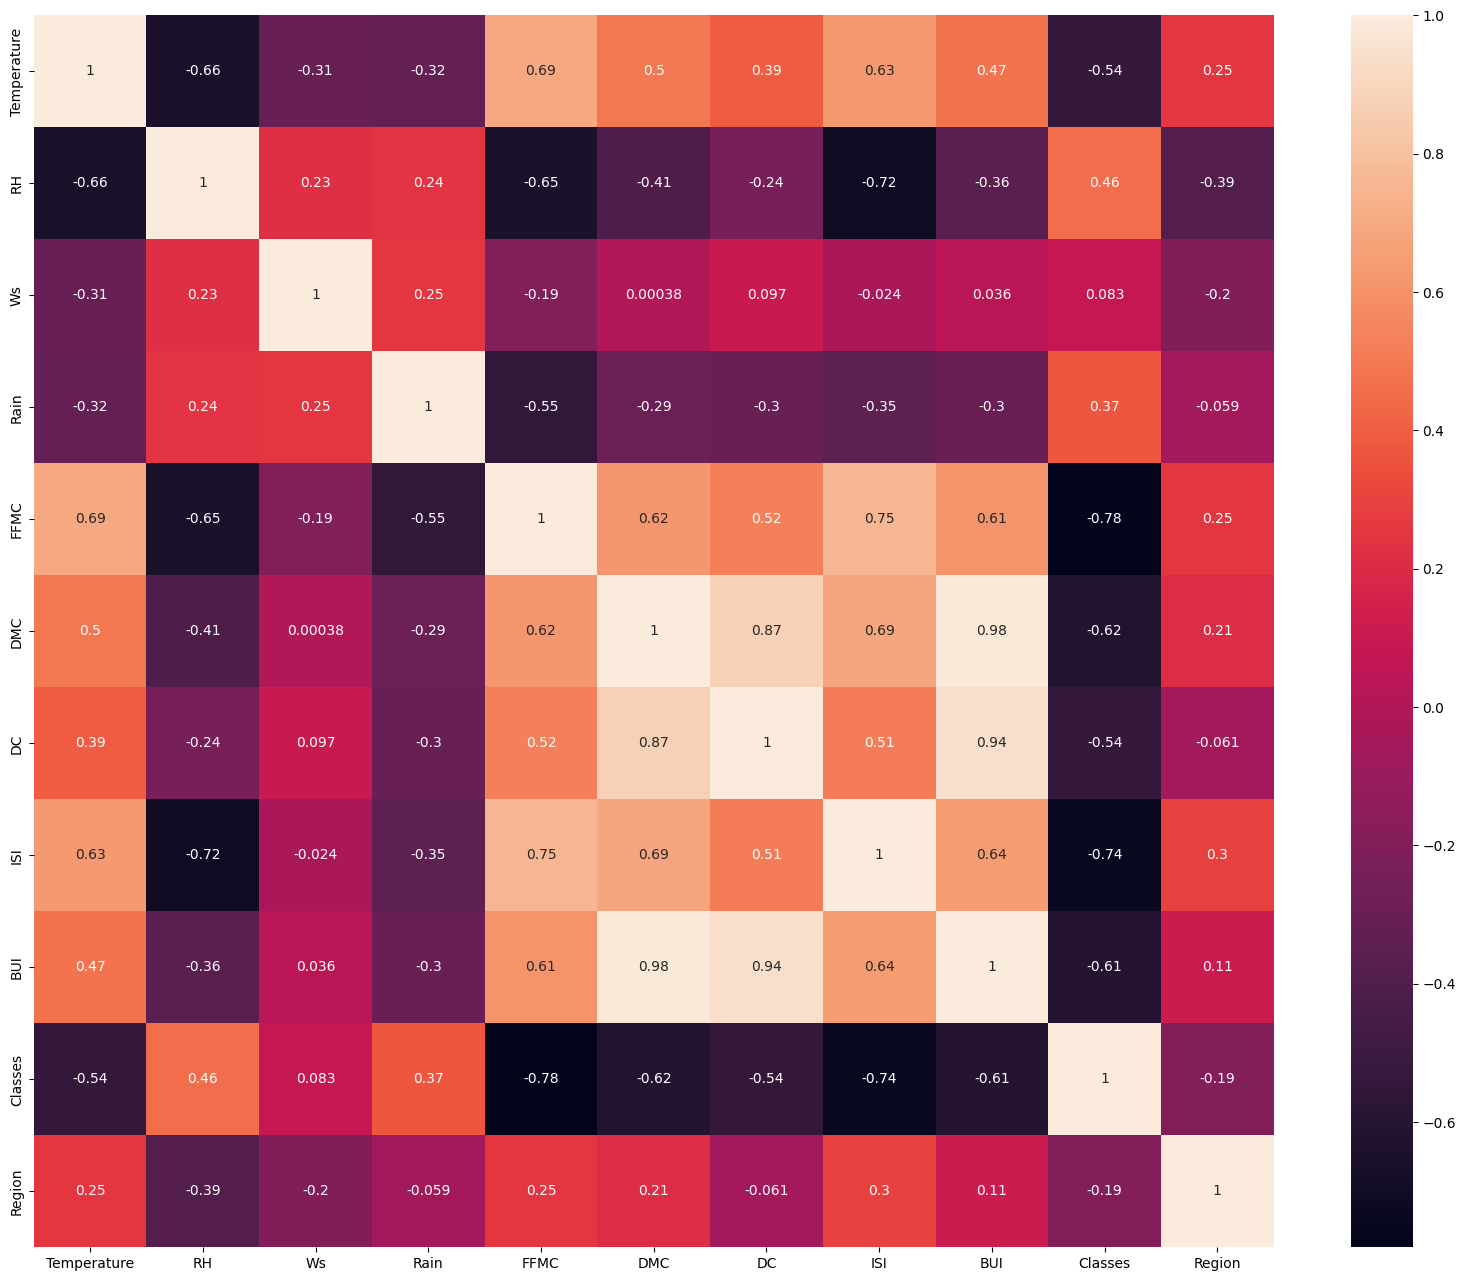

In [25]:
## check for multicollinearity
plt.figure(figsize=(20,16))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [26]:
## function which will give feature which are highly +ve co related as per the threshold and we can remove them

def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [30]:
correlation(X_train,0.90)

{'BUI'}

In [31]:
correlation(X_train,0.85)

{'BUI', 'DC'}

In [32]:
## threshold is set by domain expert


In [33]:
## drop features when correlation is more than 0.8
corr_features = correlation(X_train,0.8)

In [38]:
X_train.drop(corr_features,inplace=True,axis=1)
X_test.drop(corr_features,inplace=True,axis=1)

In [35]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
97,29,74,19,0.1,75.8,3.6,2.1,1,0
141,31,72,14,0.2,60.2,3.8,0.8,1,1
192,40,31,15,0.0,94.2,22.5,16.6,0,1
68,32,60,18,0.3,77.1,11.3,2.2,1,0
119,32,47,14,0.7,77.5,7.1,1.8,1,0
...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,0.2,1,0
14,28,80,17,3.1,49.4,3.0,0.4,1,0
92,25,76,17,7.2,46.0,1.3,0.2,1,0
179,34,59,16,0.0,88.1,19.5,7.4,0,1


In [39]:
X_test

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
24,31,64,15,0.0,86.7,14.2,5.7,0,0
6,33,54,13,0.0,88.2,9.9,6.4,0,0
152,28,58,18,2.2,63.7,3.2,1.2,1,1
232,34,58,13,0.2,79.5,18.7,2.1,1,1
238,30,65,14,0.0,85.4,16.0,4.5,0,1
...,...,...,...,...,...,...,...,...,...
162,34,56,15,2.9,74.8,7.1,1.6,1,1
178,33,57,16,0.0,87.5,15.7,6.7,0,1
224,31,72,14,0.0,84.2,8.3,3.8,0,1
230,36,33,13,0.1,90.6,25.8,9.0,0,1


In [40]:
## feature scaling or standardization
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()

In [42]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
X_test_scaled

array([[-3.01758418e-01,  1.15223531e-01, -2.19053977e-01,
        -3.84060174e-01,  6.33218240e-01, -4.25075679e-02,
         2.03772218e-01, -9.05538514e-01, -9.89070710e-01],
       [ 2.39325642e-01, -5.52632606e-01, -9.78441098e-01,
        -3.84060174e-01,  7.37980727e-01, -3.83352062e-01,
         3.65823283e-01, -9.05538514e-01, -9.89070710e-01],
       [-1.11338451e+00, -2.85490151e-01,  9.20026704e-01,
         6.45241658e-01, -9.73139891e-01, -9.14435344e-01,
        -8.37984627e-01,  1.10431526e+00,  1.01105006e+00],
       [ 5.09867672e-01, -2.85490151e-01, -9.78441098e-01,
        -2.90487280e-01,  1.30358303e-01,  3.14190159e-01,
        -6.29633258e-01,  1.10431526e+00,  1.01105006e+00],
       [-5.72300448e-01,  1.82009145e-01, -5.98747538e-01,
        -3.84060174e-01,  5.42424085e-01,  1.00171523e-01,
        -7.40296073e-02, -9.05538514e-01,  1.01105006e+00],
       [ 1.86257782e+00,  1.15223531e-01, -2.49721534e+00,
         1.77377189e-01, -2.67739147e-01, -2.406729

In [46]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
         1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
         1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
        -0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
         1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
        -0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
         1.10431526, -0.98907071]], shape=(182, 9))

## box plots to understand effect of standard scaler


Text(0.5, 1.0, 'X_train after scalling')

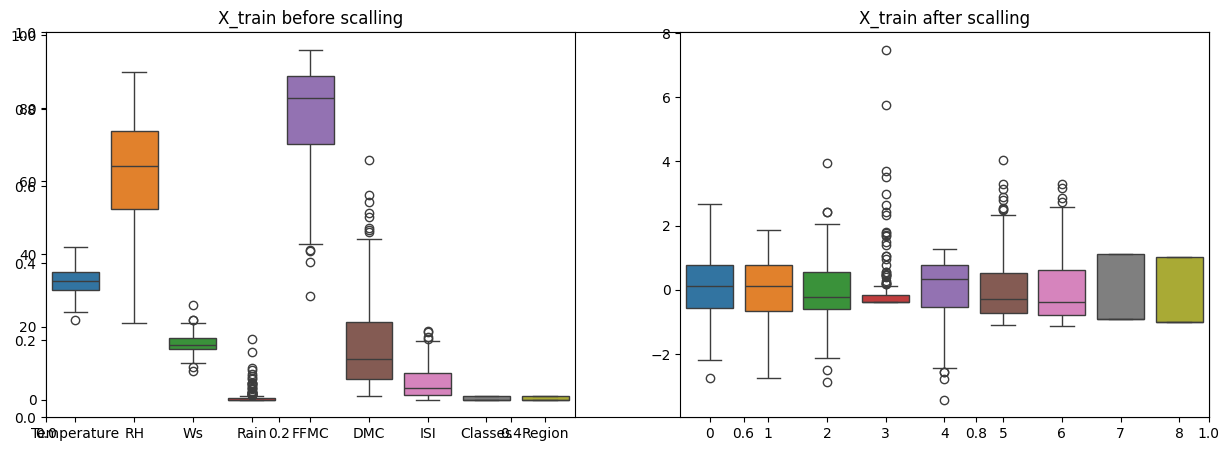

In [47]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train before scalling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train after scalling')


# Linear Regression

Mean Absoulute Error =  0.5468236465249974
R2 Score =  0.9847657384266952


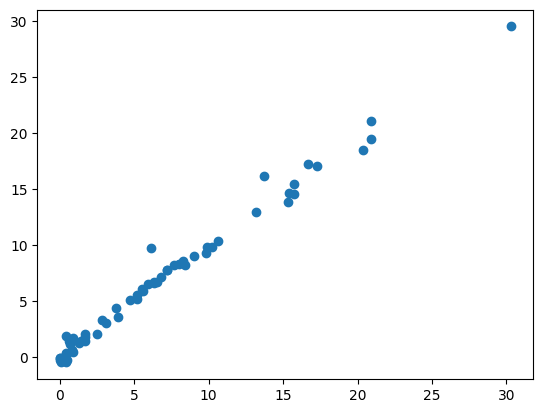

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg = LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred = linreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absoulute Error = ",mae)
print("R2 Score = ",score)
plt.scatter(y_test,y_pred)

# Lasso Regression

Mean Absoulute Error =  1.1331759949144087
R2 Score =  0.9492020263112388


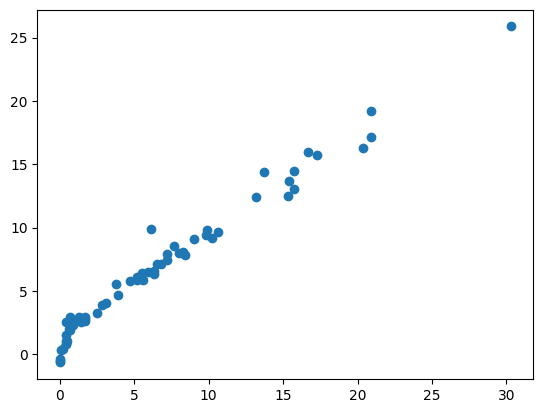

In [55]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
model = Lasso()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absoulute Error = ",mae)
print("R2 Score = ",score)
plt.scatter(y_test,y_pred)

# Lasso Cross Validation

Mean Absoulute Error =  0.6199701158263435
R2 Score =  0.9820946715928275


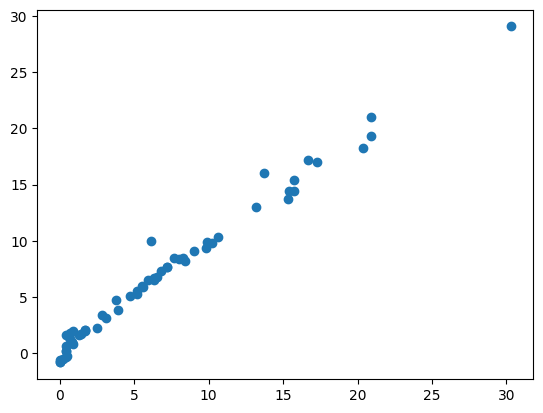

In [73]:
from sklearn.linear_model import LassoCV
lcv = LassoCV(cv=5)
lcv.fit(X_train_scaled,y_train)
y_pred = lcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absoulute Error = ",mae)
print("R2 Score = ",score)
plt.scatter(y_test,y_pred)

In [61]:
lcv.alpha_,lcv.alphas_,lcv.mse_path_

(np.float64(0.05725391318234408),
 array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
        4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
        3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
        2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
        1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
        1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
        0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
        0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
        0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
        0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
        0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
        0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
        0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
        0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
        0.0533

# Ridge Regression

Mean Absoulute Error =  0.5642305340105691
R2 Score =  0.9842993364555513


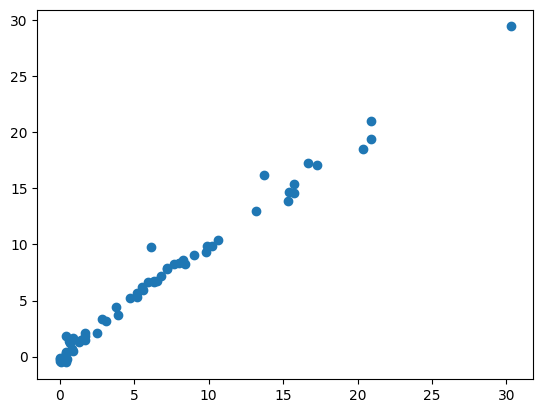

In [62]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
model_r = Ridge()
model_r.fit(X_train_scaled,y_train)
y_pred = model_r.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absoulute Error = ",mae)
print("R2 Score = ",score)
plt.scatter(y_test,y_pred)

# Ridge Cross Validation

Mean Absoulute Error =  0.5642305340105691
R2 Score =  0.9842993364555513


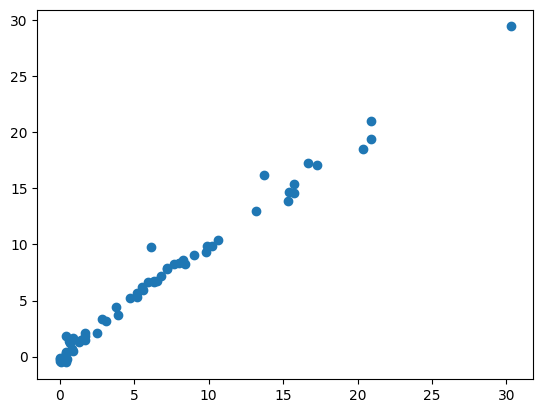

In [74]:
from sklearn.linear_model import RidgeCV
rcv = RidgeCV(cv=5)
rcv.fit(X_train_scaled,y_train)
y_pred = rcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absoulute Error = ",mae)
print("R2 Score = ",score)
plt.scatter(y_test,y_pred)

In [75]:
rcv.alpha_,rcv.alphas

(np.float64(1.0), (0.1, 1.0, 10.0))

# ELastic Net

Mean Absoulute Error =  1.8822353634895999
R2 Score =  0.8753460589519704


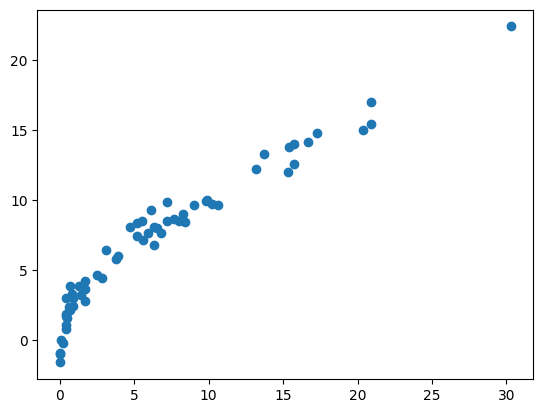

In [67]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ENet = ElasticNet()
ENet.fit(X_train_scaled,y_train)
y_pred = ENet.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absoulute Error = ",mae)
print("R2 Score = ",score)
plt.scatter(y_test,y_pred)

# Elastic Net Cross Validation

Mean Absoulute Error =  0.6575946731430904
R2 Score =  0.9814217587854941


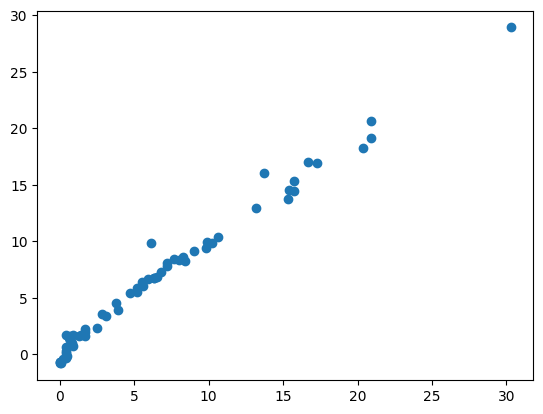

In [76]:
from sklearn.linear_model import ElasticNetCV
encv = ElasticNetCV(cv=5)
encv.fit(X_train_scaled,y_train)
y_pred = encv.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absoulute Error = ",mae)
print("R2 Score = ",score)
plt.scatter(y_test,y_pred)

In [77]:
encv.alpha_

np.float64(0.04311146156383891)

In [78]:
encv.alphas_

array([14.11706004, 13.16561744, 12.27829889, 11.45078264, 10.67903821,
        9.95930678,  9.28808283,  8.66209714,  8.07830078,  7.53385034,
        7.02609405,  6.55255882,  6.11093829,  5.6990815 ,  5.31498248,
        4.95677045,  4.62270071,  4.31114616,  4.02058933,  3.74961507,
        3.49690356,  3.26122397,  3.04142839,  2.83644629,  2.64527931,
        2.46699633,  2.30072904,  2.1456676 ,  2.00105679,  1.86619226,
        1.74041714,  1.62311885,  1.51372607,  1.411706  ,  1.31656174,
        1.22782989,  1.14507826,  1.06790382,  0.99593068,  0.92880828,
        0.86620971,  0.80783008,  0.75338503,  0.7026094 ,  0.65525588,
        0.61109383,  0.56990815,  0.53149825,  0.49567705,  0.46227007,
        0.43111462,  0.40205893,  0.37496151,  0.34969036,  0.3261224 ,
        0.30414284,  0.28364463,  0.26452793,  0.24669963,  0.2300729 ,
        0.21456676,  0.20010568,  0.18661923,  0.17404171,  0.16231189,
        0.15137261,  0.1411706 ,  0.13165617,  0.12278299,  0.11